
Analyzing Booking Trends in the Hospitality Industry

In [64]:
# Import library needed
# Pandas is used for data manipulation and analysis
import pandas as pd

# NumPy is used for numerical operations
import numpy as np

# Matplotlib is used for creating charts and visualizations
import matplotlib.pyplot as plt

# Seaborn creates advanced statistical visualizations
import seaborn as sns

# This helps display plots directly inside Jupyter Notebook
%matplotlib inline

In [65]:
# Load the dataset into a DataFrame
booking = pd.read_csv('booking - booking.csv')

# Display first 5 rows
booking.head()

,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,date of reservation,booking status
0,INN00001,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,88.00,0,10/2/2015,Not_Canceled
1,INN00002,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,11/6/2018,Not_Canceled
2,INN00003,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,50.00,0,2/28/2018,Canceled
3,INN00004,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,1,5/20/2017,Canceled
4,INN00005,1,0,1,2,Not Selected,0,Room_Type 1,48,Online,0,0,0,77.00,0,4/11/2018,Canceled


In [66]:
# Display number of rows and columns
booking.shape

(36285, 17)

In [67]:
# Display data types and missing values
booking.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36285 entries, 0 to 36284
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Booking_ID                36285 non-null  object 
 1   number of adults          36285 non-null  int64  
 2   number of children        36285 non-null  int64  
 3   number of weekend nights  36285 non-null  int64  
 4   number of week nights     36285 non-null  int64  
 5   type of meal              36285 non-null  object 
 6   car parking space         36285 non-null  int64  
 7   room type                 36285 non-null  object 
 8   lead time                 36285 non-null  int64  
 9   market segment type       36285 non-null  object 
 10  repeated                  36285 non-null  int64  
 11  P-C                       36285 non-null  int64  
 12  P-not-C                   36285 non-null  int64  
 13  average price             36285 non-null  float64
 14  specia

In [68]:
# Generate summary statistics
booking.describe()

,number of adults,number of children,number of weekend nights,number of week nights,car parking space,lead time,repeated,P-C,P-not-C,average price,special requests
count,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000
mean,1.844839,0.105360,0.810693,2.204602,0.030977,85.239851,0.025630,0.023343,0.153369,103.421636,0.619733
std,0.518813,0.402704,0.870590,1.410946,0.173258,85.938796,0.158032,0.368281,1.753931,35.086469,0.786262
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,0.000000,17.000000,0.000000,0.000000,0.000000,80.300000,0.000000
50%,2.000000,0.000000,1.000000,2.000000,0.000000,57.000000,0.000000,0.000000,0.000000,99.450000,0.000000
75%,2.000000,0.000000,2.000000,3.000000,0.000000,126.000000,0.000000,0.000000,0.000000,120.000000,1.000000
max,4.000000,10.000000,7.000000,17.000000,1.000000,443.000000,1.000000,13.000000,58.000000,540.000000,5.000000


In [69]:
# Check missing values in each column
booking.isnull().sum()

Booking_ID                  0
number of adults            0
number of children          0
number of weekend nights    0
number of week nights       0
type of meal                0
car parking space           0
room type                   0
lead time                   0
market segment type         0
repeated                    0
P-C                         0
P-not-C                     0
average price               0
special requests            0
date of reservation         0
booking status              0
dtype: int64

In [70]:
# Check duplicate records
booking.duplicated().sum()

np.int64(0)

In [71]:
# Remove duplicate rows
booking = booking.drop_duplicates()

EDA helps us understand patterns, relationships, and trends.

In [72]:
# Count booking status categories
booking['booking status'].value_counts()

booking status
Not_Canceled    24396
Canceled        11889
Name: count, dtype: int64

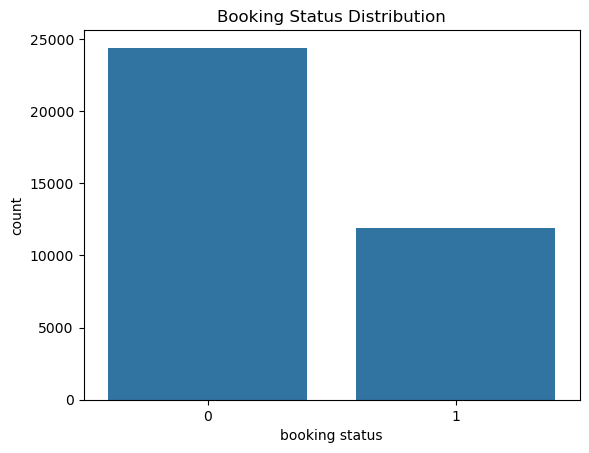

In [88]:
#Visulaization 
# Plot booking cancellation distribution
sns.countplot(x='booking status', data=booking)

# Add title
plt.title('Booking Status Distribution')
plt.savefig("chart28.png", dpi=300, bbox_inches='tight')

# Show plot
plt.show()

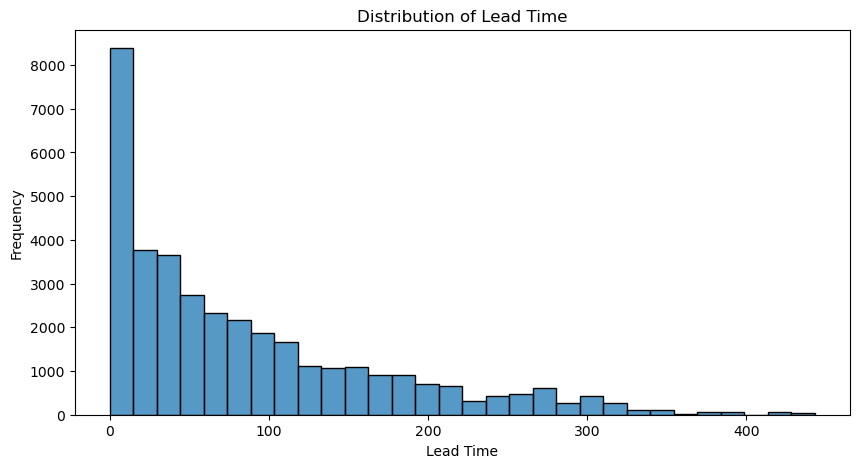

In [74]:
#Analyze Lead Time

# Create histogram for lead time
plt.figure(figsize=(10,5))

sns.histplot(booking['lead time'], bins=30)

plt.title('Distribution of Lead Time')
plt.xlabel('Lead Time')
plt.ylabel('Frequency')
plt.savefig("chart21.png", dpi=300, bbox_inches='tight')
plt.show()

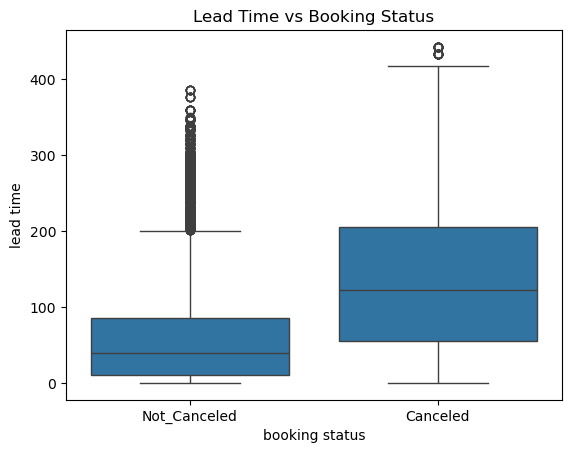

In [75]:
#Relationship Between Lead Time and Cancellation
# Compare lead time by booking status
sns.boxplot(x='booking status', y='lead time', data=booking)

plt.title('Lead Time vs Booking Status')
plt.savefig("chart22.png", dpi=300, bbox_inches='tight')

plt.show()

In [76]:
#Analyze Market Segment
# Count market segment types
booking['market segment type'].value_counts()

market segment type
Online           23221
Offline          10531
Corporate         2017
Complementary      391
Aviation           125
Name: count, dtype: int64

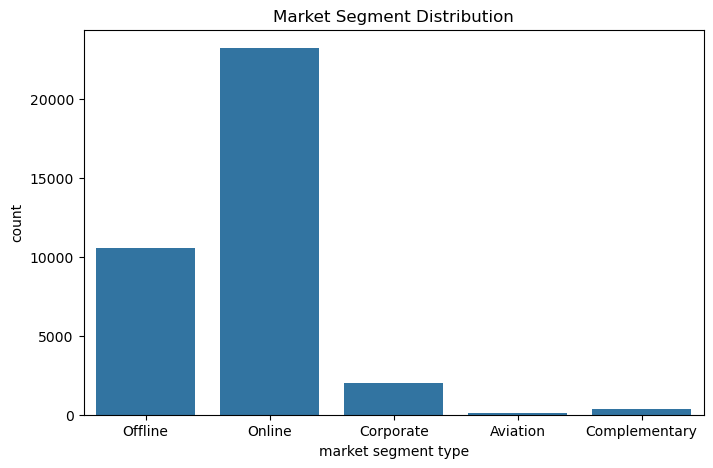

In [77]:

plt.figure(figsize=(8,5))

sns.countplot(x='market segment type', data=booking)

plt.title('Market Segment Distribution')
plt.savefig("chart23.png", dpi=300, bbox_inches='tight')

plt.show()




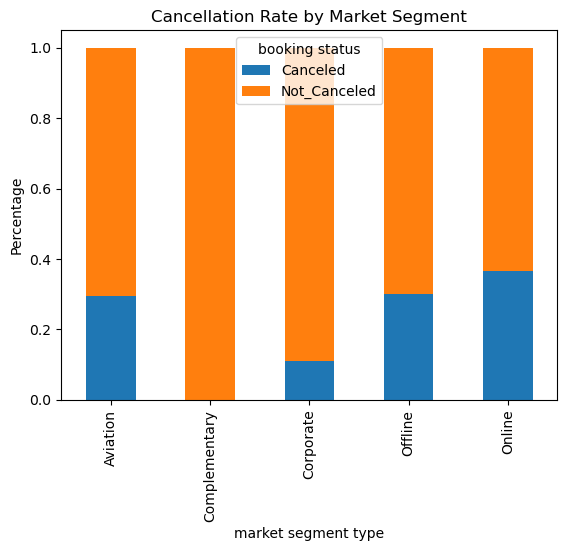

In [78]:
#Cancellation Rate by Market Segment
# Calculate cancellation percentage by market segment
segment_cancel = pd.crosstab(
    booking['market segment type'],
    booking['booking status'],
    normalize='index'
)

# Plot stacked bar chart
segment_cancel.plot(kind='bar', stacked=True)

plt.title('Cancellation Rate by Market Segment')
plt.ylabel('Percentage')
plt.savefig("chart25.png", dpi=300, bbox_inches='tight')

plt.show()



<function matplotlib.pyplot.show(close=None, block=None)>

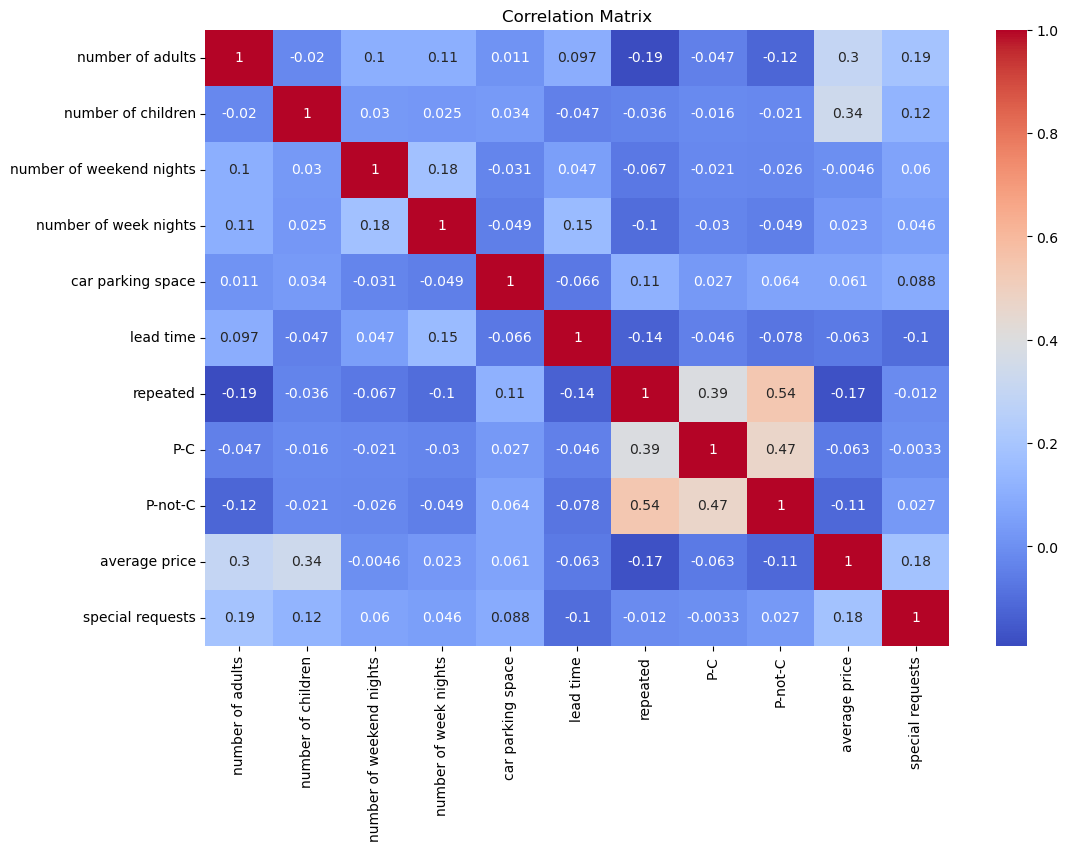

In [79]:
# Correlation Analysis
# Select only numeric columns
numeric_data = booking.select_dtypes(include=np.number)

# Create correlation matrix
corr_matrix = numeric_data.corr()

# Plot heatmap
plt.figure(figsize=(12,8))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

plt.title('Correlation Matrix')
plt.savefig("chart26.png", dpi=300, bbox_inches='tight')

plt.show

In [80]:
#FEATURE ENGINEERING
#Feature engineering improves model performance
# Convert date column into datetime format with error handling
booking['date of reservation'] = pd.to_datetime(
    booking['date of reservation'],
    format='mixed',  # Allows pandas to infer format for each element individually
    errors='coerce'  # Convert invalid dates to NaT (Not a Time) instead of raising error
)

# Optional: Check for any invalid dates that were converted to NaT
invalid_dates = booking['date of reservation'].isna().sum()
if invalid_dates > 0:
    print(f"Warning: {invalid_dates} invalid dates were found and converted to NaT")

In [81]:
# Extract reservation month
booking['reservation_month'] = booking['date of reservation'].dt.month

In [82]:
#Encode Target Variable
# Convert target variable into numeric values
booking['booking status'] = booking['booking status'].map({
    'Canceled': 1,
    'Not_Canceled': 0
})

In [83]:
#One-Hot Encoding Categorical Variables
# Convert categorical variables into dummy variables
booking = pd.get_dummies(
    booking,
    columns=[
        'type of meal',
        'room type',
        'market segment type'
    ],
    drop_first=True
)

In [84]:
# Define features
X = booking.drop([
    'Booking_ID',
    'booking status',
    'date of reservation'
], axis=1)

# Define target
y = booking['booking status']

In [85]:
#Train-Test Split
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42  # Added missing closing parenthesis
)

In [86]:
# FEATURE SCALING
from sklearn.preprocessing import StandardScaler

# Create scaler object
scaler = StandardScaler()

# Fit and transform training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform testing data
X_test_scaled = scaler.transform(X_test)

In [89]:
#MACHINE LEARNING MODEL
#Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer  # Import imputer to handle missing values
import numpy as np

# Check for missing values in your data
print("Missing values in X_train_scaled:", np.isnan(X_train_scaled).sum())

# Option 1: Fill missing values with mean (recommended for numerical data)
imputer = SimpleImputer(strategy='mean')  # You can also use 'median' or 'most_frequent'
X_train_cleaned = imputer.fit_transform(X_train_scaled)

# Alternative Option 2: Drop rows with missing values (uncomment if preferred)
# mask = ~np.isnan(X_train_scaled).any(axis=1)
# X_train_cleaned = X_train_scaled[mask]
# y_train_cleaned = y_train[mask]

# Create model
log_model = LogisticRegression()

# Train model with cleaned data
log_model.fit(X_train_cleaned, y_train)  # Use cleaned data without NaN values


Missing values in X_train_scaled: 30


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'
